In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
file_path = "breast_cancer/data.csv"
with open(file_path) as file:
    csvFile = pd.read_csv(file)
    df = pd.DataFrame(csvFile)
    print(df.keys())

area = df["area_mean"]
concavity = df["concavity_mean"]
diagnosis = df["diagnosis"] 

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


(0.0, 0.3)

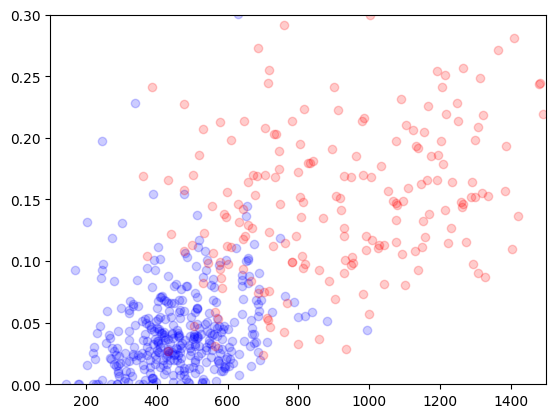

In [2]:
indices_m = [i for i in range(len(diagnosis)) if diagnosis[i]=="M" ]
diagnosis_m = diagnosis[indices_m]
area_m = area[indices_m]
concavity_m = concavity[indices_m]

indices_b = [i for i in range(len(diagnosis)) if diagnosis[i]=="B" ]
diagnosis_b = diagnosis[indices_b]
area_b = area[indices_b]
concavity_b = concavity[indices_b]

plt.scatter(area_b, concavity_b,  color="b", alpha=0.2)
plt.scatter(area_m, concavity_m,  color="r", alpha=0.2)
plt.xlim([100, 1500])
plt.ylim([0, 0.3])

In [3]:
import numpy as np
class Predictor:
    """
    I made this to translate between non-normalized queries, using a normalized model.
    """
    def __init__(self, X: list, y: list, classifier):
        X = np.array(X)
        X_normalized = self.normalize_training_data(X)
        
        self.classifier = classifier
        self.classifier.fit(X_normalized, y)
    
    def normalize_training_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)
        min_max_values = np.zeros((X.shape[1], 2))

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - np.min(X[:, i])) / (np.max(X[:, i]) - np.min(X[:, i]))
            min_max_values[i, 0] = np.min(X[:, i])
            min_max_values[i, 1] = np.max(X[:, i])
        
        self.min_max_training_values = min_max_values

        return new_X
    
    def normalize_test_data(self, X):
        X = np.array(X)
        num_feature_types = X.shape[1]
        new_X = np.zeros_like(X)

        for i in range(num_feature_types):
            new_X[:, i] = (X[:, i] - self.min_max_training_values[i, 0]) / (self.min_max_training_values[i, 1] - self.min_max_training_values[i, 0])
        
        return new_X

    def predict(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict(X_normalized)
    
    def predict_proba(self, X):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.predict_proba(X_normalized)
    
    def score(self, X, y):
        X_normalized = self.normalize_test_data(X)
        return self.classifier.score(X_normalized, y)

In [4]:

from sklearn.model_selection import train_test_split

MALIGNANT = 1
BENIGN = -1

X = np.array([[a, c] for a, c in zip(area, concavity)])
y = np.array([MALIGNANT if d=="M" else BENIGN for d in diagnosis])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(fit_intercept=True)
clf = LogisticRegression(fit_intercept=True, solver="newton-cholesky", penalty=None, max_iter=100000, tol=1e-9)
predictor = Predictor(X_train, y_train, clf)

/home/wyrgly/projects/coursework/winter2026/ecen471/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [6]:
predictor.classifier.coef_
predictor.classifier.intercept_
1-predictor.score(X_train, y_train)

0.09670329670329669

In [7]:
@np.vectorize
def calculate_Z(x, y):
    return predictor.predict_proba(np.array([[x, y]]))[0][1]

x1 = np.linspace(100, 2600, 1000)
x2 = np.linspace(0, 0.5, 1000)
X1, X2 = np.meshgrid(x1, x2)
Z = calculate_Z(X1, X2)

In [8]:
def scatter_data(ax, X, y):
    # diagnosis_m = [y[i] for i in range(len(y)) if y[i]==1 ]
    area_m = [X[i, 0] for i in range(len(y)) if y[i]==MALIGNANT ]
    concavity_m = [X[i, 1] for i in range(len(y)) if y[i]==MALIGNANT ]

    # diagnosis_b = [y[i] for i in range(len(y)) if y[i]==-1 ]
    area_b = [X[i, 0] for i in range(len(y)) if y[i]==BENIGN ]
    concavity_b = [X[i, 1] for i in range(len(y)) if y[i]==BENIGN ]
    ax.scatter(area_b, concavity_b, color="blue", s=10)
    ax.scatter(area_m, concavity_m, color="red", s=10)

Text(0.5, 1.0, 'Test Data')

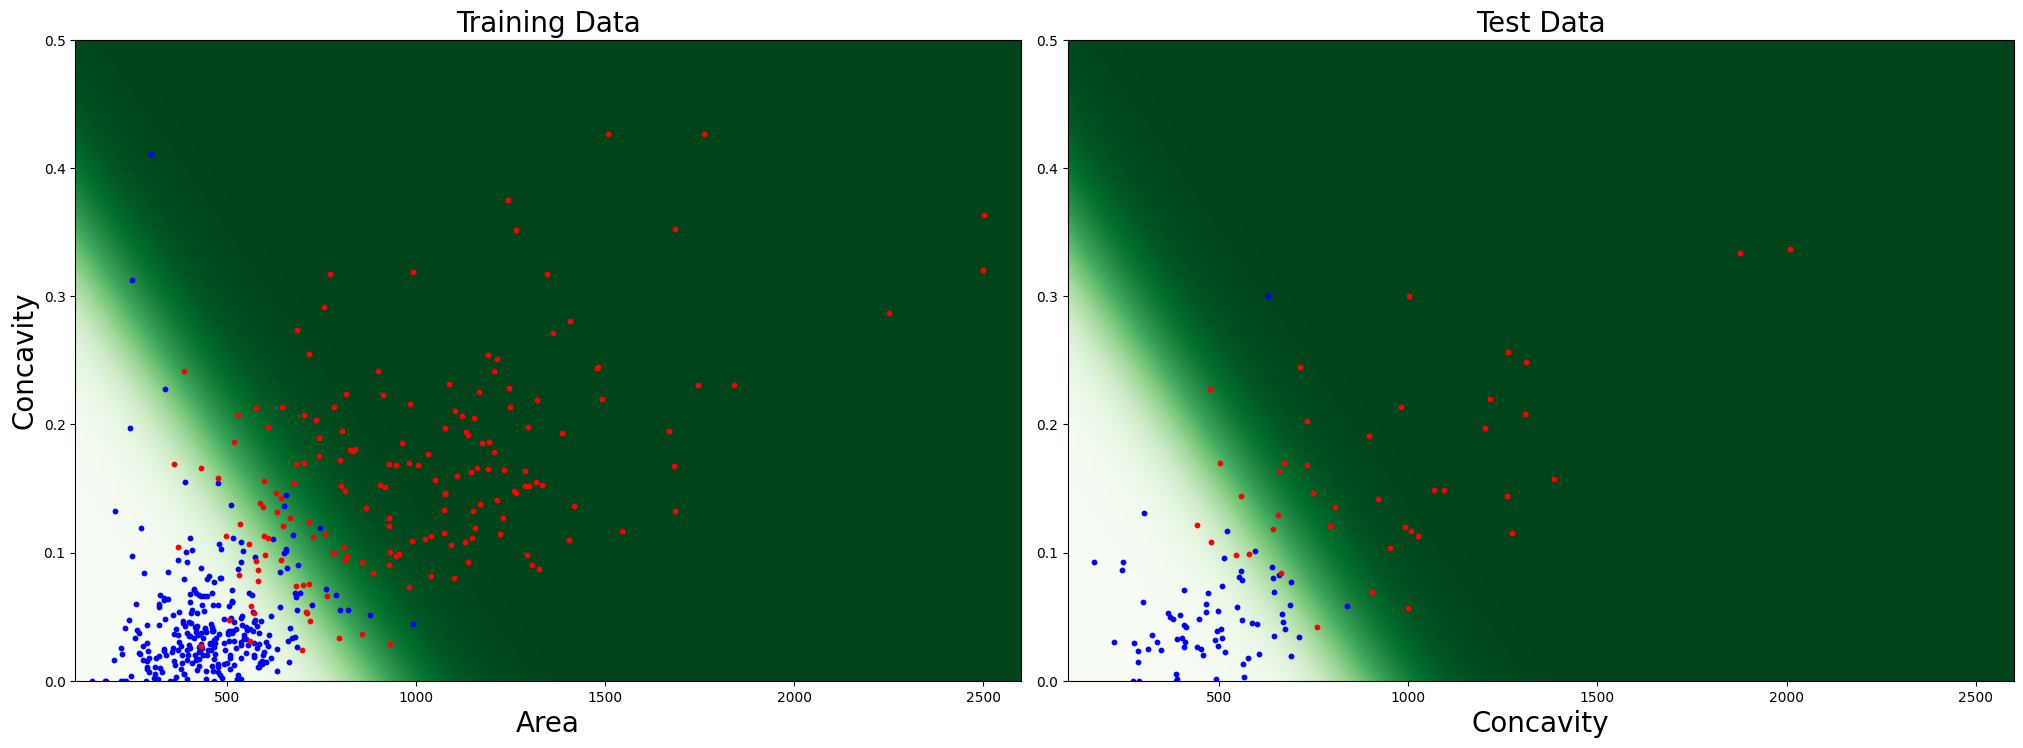

In [9]:
import matplotlib.cm as cm
from matplotlib import colormaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# cmap = cm.get_cmap('viridis')
# plt.figure(figsize=(12, 8))
cmap = colormaps["Greens"]
# cmap = colormaps["YlGn"] 
ax1.contourf(X1, X2, Z, levels=300, cmap=cmap)
scatter_data(ax1, X_train, y_train)

ax2.contourf(X1, X2, Z, levels=300, cmap=cmap)
# fig.colorbar()
scatter_data(ax2, X_test, y_test)
fig.tight_layout()
ax1.set_xlabel("Area", fontsize=20)
ax2.set_xlabel("Concavity", fontsize=20)

ax1.set_ylabel("Concavity", fontsize=20)
ax1.set_title("Training Data", fontsize=20)
ax2.set_title("Test Data", fontsize=20)

In [10]:
from sklearn.metrics import classification_report

def missclassification_rate(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    return 1 - report['accuracy'] # Page 63 of textbook states, "1 minus the misclassification rate as the accuracy"

print(missclassification_rate(y_train, predictor.predict(X_train)))
print(missclassification_rate(y_test, predictor.predict(X_test)))

0.09670329670329669
0.07017543859649122


In [11]:
original_coef = predictor.classifier.coef_
original_intercept = predictor.classifier.intercept_

print(original_intercept)
print(original_coef)
print(predictor.classifier.score(X_train, y_train))

[-8.00623496]
[[25.74448638 10.78158812]]
0.3758241758241758


In [25]:
import warnings
warnings.filterwarnings('ignore')
count = 0

@np.vectorize
def find_intercept(theta_1, theta_2, min=-10, max=-6, M=40):
    global count
    count += 1
    print(count)
    intercepts = np.linspace(min, max, M)
    J = np.zeros_like(intercepts)
    for i, intercept in enumerate(intercepts):
        predictor.classifier.intercept_ = intercept
        predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
        J[i] = missclassification_rate(y_train, predictor.predict(X_train))
    
    optimal_intercept = intercepts[np.argmin(J)]
    return optimal_intercept

theta1 = np.linspace(8, 60, 20)
theta2 = np.linspace(2, 35, 20)
THETA1, THETA2 = np.meshgrid(theta1, theta2)

intercepts = find_intercept(THETA1, THETA2)
print('\a')

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [ ]:
@np.vectorize
def calculate_cost_function(theta_1, theta_2, intercept):
    predictor.classifier.intercept_ = intercept
    predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
    J = missclassification_rate(y_train, predictor.predict(X_train))
    return J

J = calculate_cost_function(THETA1, THETA2, intercepts)

theta1_opt = THETA1.ravel()[np.argmin(J.ravel())]
theta2_opt = THETA2.ravel()[np.argmin(J.ravel())]
intercept_opt = intercepts.ravel()[np.argmin(J.ravel())]

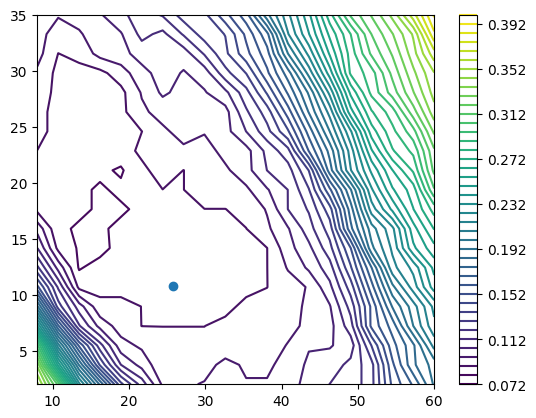

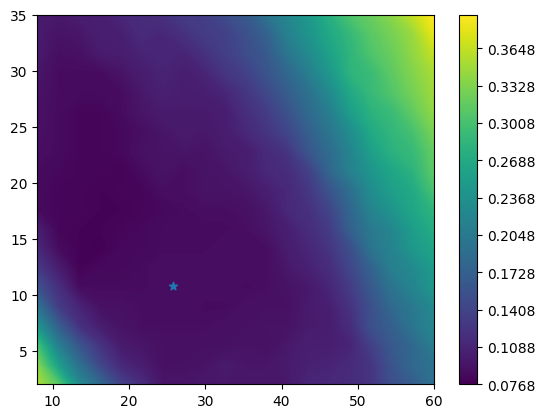

In [ ]:
contour = plt.contour(THETA1, THETA2, J, levels=50,zorder=0)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10)
plt.colorbar(contour)

plt.show()
contour =plt.contourf(THETA1, THETA2, J, levels=500,zorder=0)
plt.colorbar(contour)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10, marker="*")
# plt.xlim([20, 40])
# plt.ylim([5, 15])

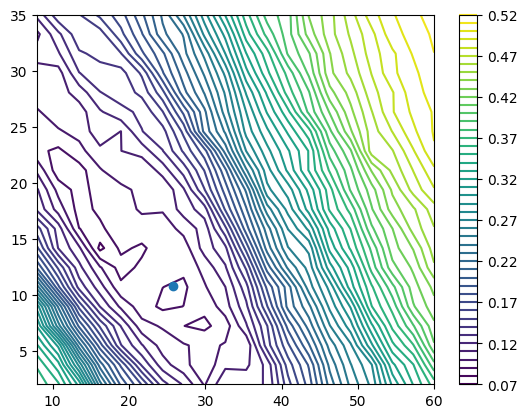

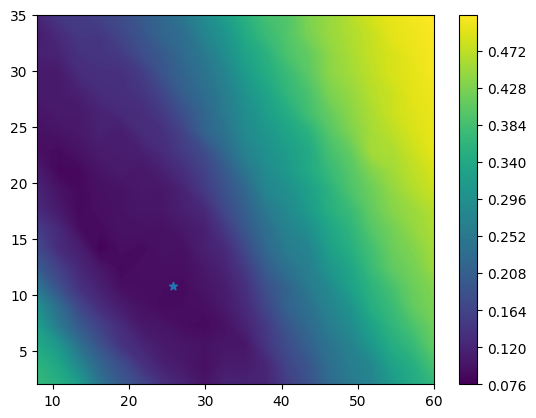

In [38]:
@np.vectorize
def calculate_cost_function(theta_1, theta_2, intercept):
    predictor.classifier.intercept_ = intercept
    predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
    J = missclassification_rate(y_train, predictor.predict(X_train))
    return J

J = calculate_cost_function(THETA1, THETA2, intercepts*0+intercept_opt)

contour = plt.contour(THETA1, THETA2, J, levels=50,zorder=0)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10)
plt.colorbar(contour)

plt.show()
contour =plt.contourf(THETA1, THETA2, J, levels=500,zorder=0)
plt.colorbar(contour)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10, marker="*")
# plt.xlim([20, 40])
# plt.ylim([5, 15])

In [28]:
predictor.classifier.intercept_ = intercept_opt
predictor.classifier.coef_ = np.array([[theta1_opt, theta2_opt]])
@np.vectorize
def calculate_Z(x, y):
    # print(predictor.classifier.coef_)
    return predictor.predict_proba(np.array([[x, y]]))[0][1]

x1 = np.linspace(100, 2600, 1000)
x2 = np.linspace(0, 0.5, 1000)
X1, X2 = np.meshgrid(x1, x2)
Z = calculate_Z(X1, X2)

In [29]:
predictor.classifier.intercept_ = intercept_opt
predictor.classifier.coef_ = np.array([[theta1_opt, theta2_opt]])
missclassification_rate(y_train, predictor.predict(X_train))

0.07692307692307687

In [30]:
predictor.score(X_train, y_train)

0.9230769230769231

In [18]:
np.min(J)

np.float64(0.07692307692307687)

In [19]:
theta1_opt
theta2_opt

np.float64(13.673469387755102)

Text(0.5, 1.0, 'Test Data')

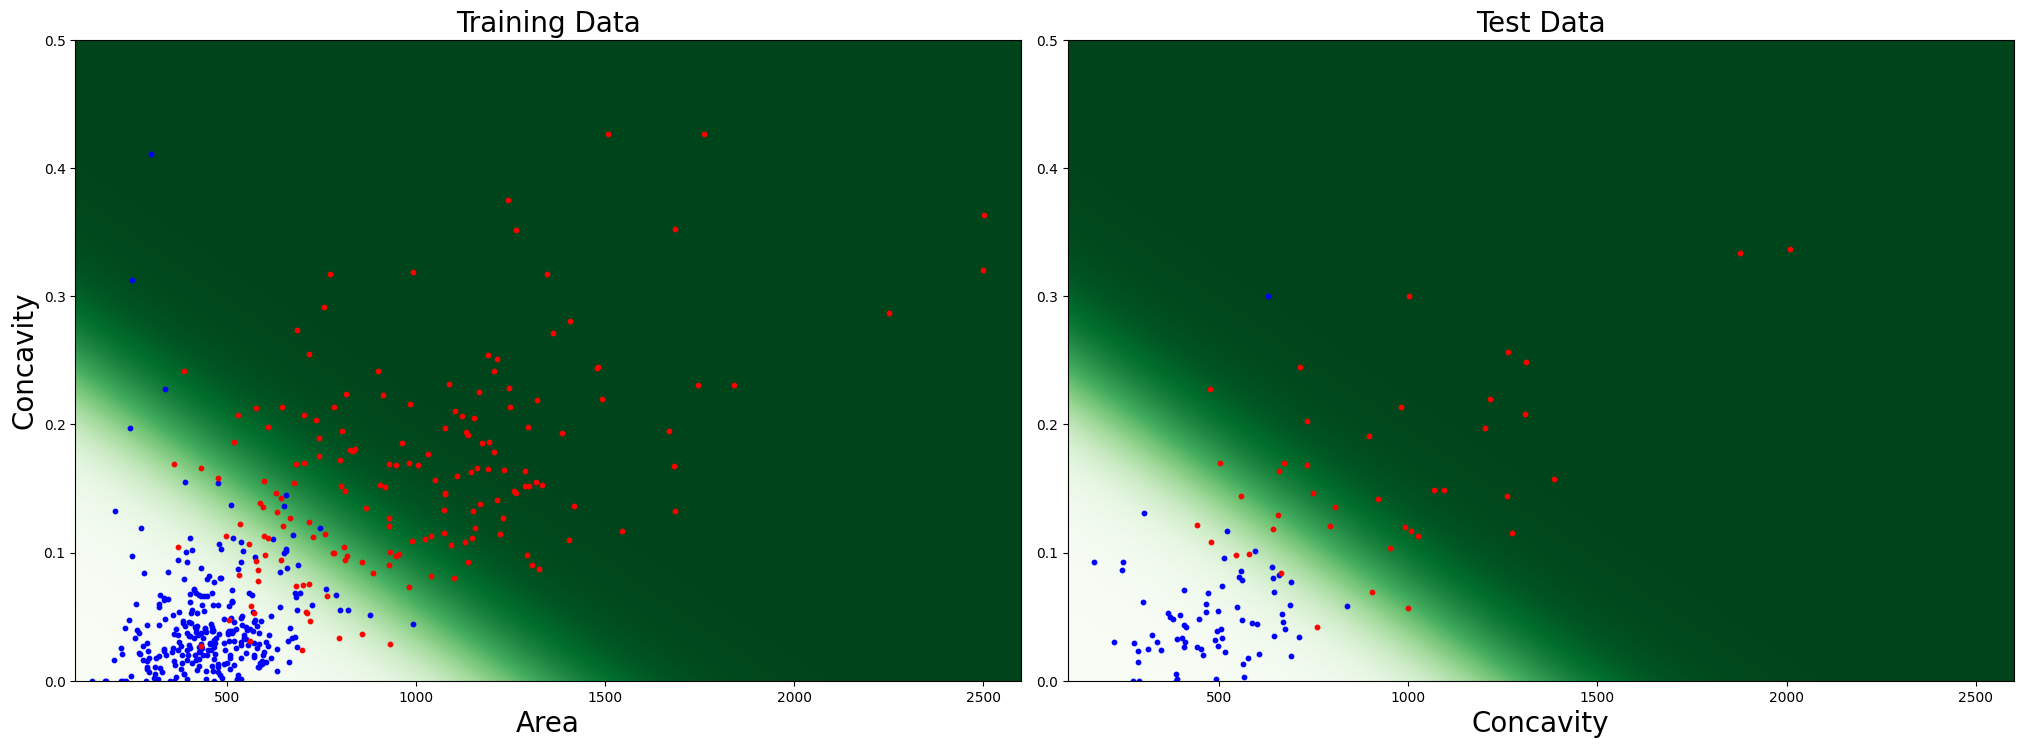

In [20]:
import matplotlib.cm as cm
from matplotlib import colormaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# cmap = cm.get_cmap('viridis')
# plt.figure(figsize=(12, 8))
cmap = colormaps["Greens"]
# cmap = colormaps["YlGn"] 
ax1.contourf(X1, X2, Z, levels=300, cmap=cmap)
scatter_data(ax1, X_train, y_train)

ax2.contourf(X1, X2, Z, levels=300, cmap=cmap)
# fig.colorbar()
scatter_data(ax2, X_test, y_test)
fig.tight_layout()
ax1.set_xlabel("Area", fontsize=20)
ax2.set_xlabel("Concavity", fontsize=20)

ax1.set_ylabel("Concavity", fontsize=20)
ax1.set_title("Training Data", fontsize=20)
ax2.set_title("Test Data", fontsize=20)

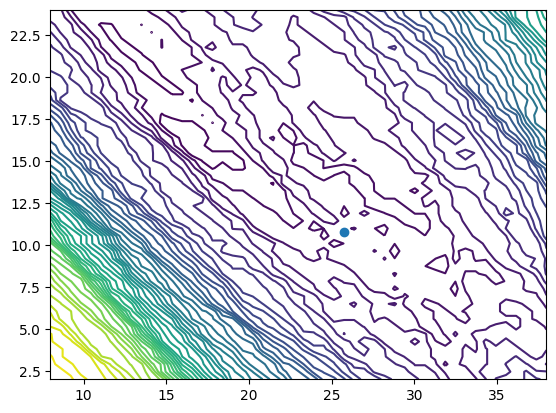

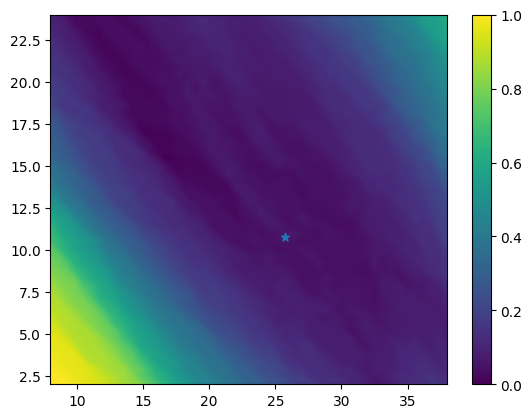

In [21]:
@np.vectorize
def calculate_cost_function(theta_1, theta_2, intercept):
    predictor.classifier.intercept_ = intercept
    predictor.classifier.coef_ = np.array([[theta_1, theta_2]])        
    J = missclassification_rate(y_train, predictor.predict(X_train))
    return J

J = calculate_cost_function(THETA1, THETA2, intercepts*0 + original_intercept)

plt.contour(THETA1, THETA2, J, levels=50,zorder=0)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10)

plt.show()
plt.contourf(THETA1, THETA2, J, levels=500,zorder=0)
plt.scatter(original_coef[0, 0], original_coef[0, 1], zorder=10, marker="*")
plt.colorbar()

In [22]:
np.max(J)-np.min(J)

np.float64(0.2901098901098901)

In [23]:
original_coef

array([[25.74448638, 10.78158812]])


0.09670329670329669


array([-12.90623496, -12.80623496, -12.70623496, -12.60623496,
       -12.50623496, -12.40623496, -12.30623496, -12.20623496,
       -12.10623496, -12.00623496, -11.90623496, -11.80623496,
       -11.70623496, -11.60623496, -11.50623496, -11.40623496,
       -11.30623496, -11.20623496, -11.10623496, -11.00623496,
       -10.90623496, -10.80623496, -10.70623496, -10.60623496,
       -10.50623496, -10.40623496, -10.30623496, -10.20623496,
       -10.10623496, -10.00623496,  -9.90623496,  -9.80623496,
        -9.70623496,  -9.60623496,  -9.50623496,  -9.40623496,
        -9.30623496,  -9.20623496,  -9.10623496,  -9.00623496,
        -8.90623496,  -8.80623496,  -8.70623496,  -8.60623496,
        -8.50623496,  -8.40623496,  -8.30623496,  -8.20623496,
        -8.10623496,  -8.00623496,  -7.90623496,  -7.80623496,
        -7.70623496,  -7.60623496,  -7.50623496,  -7.40623496,
        -7.30623496,  -7.20623496,  -7.10623496,  -7.00623496,
        -6.90623496,  -6.80623496,  -6.70623496,  -6.60

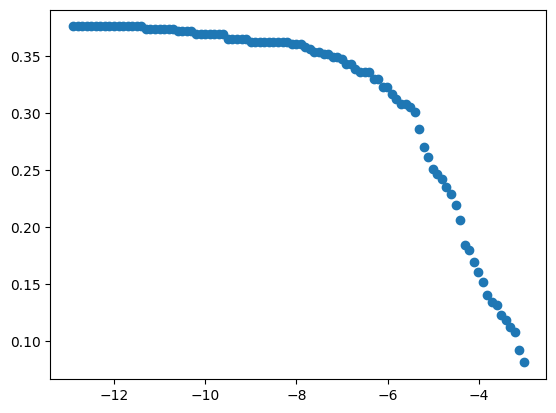

In [24]:
predictor.classifier.intercept_ = original_intercept
predictor.classifier.coef_ = original_coef
# print(predictor.classifier.intercept_)
# print(predictor.classifier.coef_)
print()


print(missclassification_rate(y_train, predictor.predict(X_train)))
# print(missclassification_rate(y_test, predictor.predict(X_test)))



current_intercept = original_intercept - 0.1*50
my_intercepts = np.zeros(100)
errors = []
for i in range(100):
    current_intercept += 0.1
    my_intercepts[i] = current_intercept[0]
    predictor.classifier.intercept_ = current_intercept
    predictor.classifier.coef_ = np.array([[6.2, 6]])
    errors.append(missclassification_rate(y_train, predictor.predict(X_train)))
    

plt.scatter(my_intercepts, errors)
my_intercepts